# MSA vs Jordanian Nets

Loaded environment variables from: /home/eman/signly/.env

[!] Training new model initialization pipeline...
Epoch [00/79] -> Train Loss: 1.8545 | Val Loss: 1.5874 | Patience: 0/10
Epoch [10/79] -> Train Loss: 0.4153 | Val Loss: 0.5554 | Patience: 0/10
Epoch [20/79] -> Train Loss: 0.1501 | Val Loss: 0.3849 | Patience: 0/10
Epoch [30/79] -> Train Loss: 0.1135 | Val Loss: 0.4677 | Patience: 2/10
Epoch [38/79] -> Train Loss: 0.0526 | Val Loss: 0.4242 | Patience: 10/10

[!] Early stopping triggered at epoch 38!


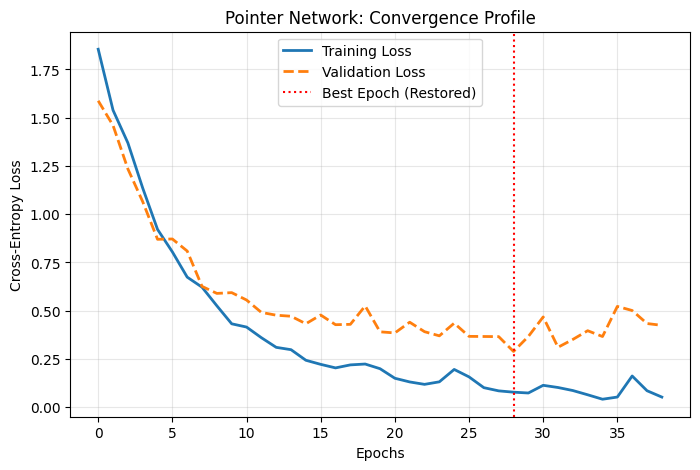

Model weights and metadata checkpoint cached to: /home/eman/signly/data/built_corpus_supa/pointer_net_weights.pth

Inference Running on 63 Aligned Test Sequences
Example 1:
Source (NLP) : حكالي اثنان صاحب أن كتاب مفيد
Target (ArSL): صاحب اثنان حكالي | أن كتاب مفيد
Prediction   : صاحب اثنان حكالي أن كتاب مفيد
--------------------------------------------------
Example 2:
Source (NLP) : قبل شفى كثير مفتاح
Target (ArSL): مفتاح كثير قبل شفى
Prediction   : مفتاح كثير قبل شفى
--------------------------------------------------
Example 3:
Source (NLP) : أن ولد جوعان قبل طلب طالب أكل
Target (ArSL): أن ولد جوعان | طالب أكل قبل طلب
Prediction   : أن ولد جوعان طالب أكل قبل طلب
--------------------------------------------------
Example 4:
Source (NLP) : موظف قبل طلب شاي
Target (ArSL): موظف شاي قبل طلب
Prediction   : موظف شاي قبل طلب
--------------------------------------------------
Example 5:
Source (NLP) : اثنان قبل قرأ طالب قبل نص ممتع طويل
Target (ArSL): طالب اثنان نص طويل ممتع قبل قرأ
Predictio

In [4]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from scipy import stats
import sys
from dotenv import load_dotenv
from collections import Counter

current_dir = os.path.abspath(os.getcwd())
root_dir = current_dir

while root_dir and not os.path.exists(os.path.join(root_dir, 'backend')):
    parent = os.path.dirname(root_dir)
    if parent == root_dir:
        break
    root_dir = parent

backend_dir = os.path.join(root_dir, 'backend')
env_path_root = os.path.join(root_dir, '.env')
env_path_backend = os.path.join(backend_dir, '.env')

if os.path.exists(env_path_root):
    load_dotenv(dotenv_path=env_path_root)
    print(f"Loaded environment variables from: {env_path_root}")
elif os.path.exists(env_path_backend):
    load_dotenv(dotenv_path=env_path_backend)
    print(f"Loaded environment variables from: {env_path_backend}")

if os.path.exists(backend_dir):
    if backend_dir not in sys.path:
        sys.path.append(backend_dir)
else:
    print(f"CRITICAL ERROR: Could not find backend directory starting from {current_dir}")

# Core NLP Utility Import
try:
    from app.core.nlp_utils import transform_to_arsl
except ImportError:
    print("[Warning] Could not import 'transform_to_arsl' from app.core.nlp_utils.")
    print("Placeholder function assigned to avoid runtime failure.")
    def transform_to_arsl(text):
        return text.split()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EMBED_MODEL = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2').to(DEVICE)
HIDDEN_DIM = 512
LR = 1e-3
BATCH_SIZE = 16
MAX_LEN = 20
NUM_EPOCHS = 80

WEIGHT_DECAY = 1e-4  # L2
DROPOUT_RATE = 0.3   
PATIENCE = 10

FORCE_RETRAIN = False  # Set to False to load checkpoint instead of training

DATA_DIR = os.path.join(root_dir, 'data', 'built_corpus_supa')
PATH_MASTER_NLP_OUT = os.path.join(DATA_DIR, 'mixed_sentences_jordanian_nlp_processed.txt')
PATH_MASTER_TARGET = os.path.join(DATA_DIR, 'mixed_sentences_jordanian_target.txt')
PATH_TRAIN_NLP_OUT = os.path.join(DATA_DIR, 'split_train-nlp-processed.txt')
PATH_TRAIN_TARGET = os.path.join(DATA_DIR, 'split_train-targets.txt')
PATH_VAL_NLP_OUT = os.path.join(DATA_DIR, 'split_val-nlp-processed.txt')
PATH_VAL_TARGET = os.path.join(DATA_DIR, 'split_val-targets.txt')
PATH_TEST_NLP_OUT = os.path.join(DATA_DIR, 'split_test-nlp-processed.txt')
PATH_TEST_TARGET = os.path.join(DATA_DIR, 'split_test-targets.txt')

MODEL_SAVE_PATH = os.path.join(DATA_DIR, 'pointer_net_weights.pth')

# Paths for extracting comparative visualizations (Modify paths as needed)
PATH_MSA_WEIGHTS = os.path.join(DATA_DIR, 'pointer_net_weights_v2.pth')
PATH_JO_WEIGHTS = os.path.join(DATA_DIR, 'pointer_net_weights_v3_jo.pth')

def split_master_dataset(src_path, tgt_path, train_ratio=0.8, val_ratio=0.1):
    if not os.path.exists(src_path) or not os.path.exists(tgt_path):
        print("Skipping dataset split: Master files not found.")
        return
        
    with open(src_path, 'r', encoding='utf-8') as f:
        src_lines = [l.strip() for l in f if l.strip()]
        
    with open(tgt_path, 'r', encoding='utf-8') as f:
        tgt_lines = []
        for l in f:
            clean_l = l.strip()
            if not clean_l: continue
            if clean_l.startswith("Output:"):
                clean_l = clean_l.replace("Output:", "", 1).strip()
            tgt_lines.append(clean_l)

    assert len(src_lines) == len(tgt_lines), "Lines mismatch!"
    total_lines = len(src_lines)
    
    combined = list(zip(src_lines, tgt_lines))
    random.seed(42) 
    random.shuffle(combined)
    src_lines_shuffled, tgt_lines_shuffled = zip(*combined)

    train_end = int(total_lines * train_ratio)
    val_end = train_end + int(total_lines * val_ratio)

    splits = {
        'train': (src_lines_shuffled[:train_end], tgt_lines_shuffled[:train_end], PATH_TRAIN_NLP_OUT, PATH_TRAIN_TARGET),
        'val': (src_lines_shuffled[train_end:val_end], tgt_lines_shuffled[train_end:val_end], PATH_VAL_NLP_OUT, PATH_VAL_TARGET),
        'test': (src_lines_shuffled[val_end:], tgt_lines_shuffled[val_end:], PATH_TEST_NLP_OUT, PATH_TEST_TARGET)
    }

    for split_name, (src_data, tgt_data, src_out_path, tgt_out_path) in splits.items():
        with open(src_out_path, 'w', encoding='utf-8') as f: f.write('\n'.join(src_data) + '\n')
        with open(tgt_out_path, 'w', encoding='utf-8') as f: f.write('\n'.join(tgt_data) + '\n')


def load_aligned_data(src_path, tgt_path):
    if not os.path.exists(src_path) or not os.path.exists(tgt_path):
        return [], []
    with open(src_path, 'r', encoding='utf-8') as f: src_lines = [l.strip() for l in f if l.strip()]
    with open(tgt_path, 'r', encoding='utf-8') as f:
        tgt_lines = []
        for l in f:
            clean_l = l.strip()
            if not clean_l: continue
            if clean_l.startswith("Output:"): clean_l = clean_l.replace("Output:", "", 1).strip()
            tgt_lines.append(clean_l)
    return src_lines, tgt_lines


class PointerDataset(Dataset):
    def __init__(self, src_lines, tgt_lines):
        self.src_lines = src_lines
        self.tgt_lines = tgt_lines

    def __len__(self): return len(self.src_lines)

    def __getitem__(self, idx):
        source_words = self.src_lines[idx].split()[:MAX_LEN]
        target_words = self.tgt_lines[idx].split()[:MAX_LEN]

        target_indices = []
        for word in target_words:
            if word in source_words: target_indices.append(source_words.index(word))
            else: target_indices.append(0)

        embeddings = EMBED_MODEL.encode(source_words)
        padded_embeds = np.zeros((MAX_LEN, 384))
        padded_embeds[:len(source_words)] = embeddings

        padded_targets = np.full(MAX_LEN, -1)
        padded_targets[:len(target_indices)] = target_indices

        return torch.FloatTensor(padded_embeds), torch.LongTensor(padded_targets), len(source_words)


class PointerAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.vt = nn.Linear(hidden_dim, 1)

    def forward(self, decoder_hidden, encoder_outputs):
        out = torch.tanh(self.W1(encoder_outputs) + self.W2(decoder_hidden).unsqueeze(1))
        scores = self.vt(out).squeeze(2)
        return scores


class PointerNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate=DROPOUT_RATE):
        super().__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.decoder = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.attention = PointerAttention(hidden_dim)
        self.reduce_h = nn.Linear(hidden_dim * 2, hidden_dim)
        self.reduce_c = nn.Linear(hidden_dim * 2, hidden_dim)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        x = self.dropout(x)
        enc_out, (h_n, c_n) = self.encoder(x)
        enc_out = self.dropout(enc_out)

        h_d = self.reduce_h(torch.cat((h_n[0], h_n[1]), dim=1)).unsqueeze(0)
        c_d = self.reduce_c(torch.cat((c_n[0], c_n[1]), dim=1)).unsqueeze(0)

        enc_out_reduced = enc_out[:, :, :HIDDEN_DIM] + enc_out[:, :, HIDDEN_DIM:]
        all_logits = []
        decoder_input = torch.zeros(batch_size, 1, HIDDEN_DIM).to(DEVICE)

        for _ in range(seq_len):
            _, (h_d, c_d) = self.decoder(decoder_input, (h_d, c_d))
            h_d_dropped = self.dropout(h_d)
            logits = self.attention(h_d_dropped.squeeze(0), enc_out_reduced)
            all_logits.append(logits)

        return torch.stack(all_logits, dim=1)


def plot_convergence(history, best_epoch_idx):
    """Plots single-model convergence metrics."""
    plt.figure(figsize=(8, 5))
    plt.plot(history['train_loss'], label='Training Loss', lw=2)
    plt.plot(history['val_loss'], label='Validation Loss', lw=2, linestyle='--')
    
    if best_epoch_idx >= 0:
        plt.axvline(x=best_epoch_idx, color='r', linestyle=':', label='Best Epoch (Restored)')
        
    plt.title("Pointer Network: Convergence Profile")
    plt.xlabel("Epochs")
    plt.ylabel("Cross-Entropy Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def train_and_validate(train_loader, val_loader, patience=PATIENCE):
    model = PointerNet(384, HIDDEN_DIM).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    history = {'train_loss': [], 'val_loss': []}

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_weights = None

    for epoch in range(NUM_EPOCHS):
        model.train()
        train_loss = 0
        for x, y, _ in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output.view(-1, MAX_LEN), y.view(-1))
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y, _ in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                output = model(x)
                loss = criterion(output.view(-1, MAX_LEN), y.view(-1))
                val_loss += loss.item()

        avg_train = train_loss / len(train_loader)
        avg_val = val_loss / len(val_loader)
        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            patience_counter = 0
            best_model_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1

        if epoch % 10 == 0 or epoch == NUM_EPOCHS - 1 or patience_counter >= patience:
            print(f"Epoch [{epoch:02d}/{NUM_EPOCHS-1}] -> Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f} | Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"\n[!] Early stopping triggered at epoch {epoch}!")
            break
     
    if best_model_weights is not None:
        model.load_state_dict(best_model_weights)
        
    best_epoch_idx = len(history['val_loss']) - patience_counter - 1
    plot_convergence(history, best_epoch_idx)
    
    return model, history, best_epoch_idx


def compute_bootstrap_ci(metrics_list, confidence=0.95, n_resamples=1000):
    if not metrics_list: return 0.0, 0.0, 0.0
    means = []
    for _ in range(n_resamples):
        sample = random.choices(metrics_list, k=len(metrics_list))
        means.append(np.mean(sample))
    lower = np.percentile(means, ((1 - confidence) / 2) * 100)
    upper = np.percentile(means, (1 - (1 - confidence) / 2) * 100)
    return np.mean(metrics_list), lower, upper


def compute_wer(reference_words, predicted_words):
    """Calculates Word Error Rate (WER) using Levenshtein distance."""
    if not reference_words: return 1.0
    d = np.zeros((len(reference_words) + 1, len(predicted_words) + 1))
    for i in range(len(reference_words) + 1): d[i, 0] = i
    for j in range(len(predicted_words) + 1): d[0, j] = j
    
    for i in range(1, len(reference_words) + 1):
        for j in range(1, len(predicted_words) + 1):
            cost = 0 if reference_words[i - 1] == predicted_words[j - 1] else 1
            d[i, j] = min(
                d[i - 1, j] + 1,        # Deletion
                d[i, j - 1] + 1,        # Insertion
                d[i - 1, j - 1] + cost   # Substitution
            )
    return d[len(reference_words), len(predicted_words)] / len(reference_words)


def compute_per(reference_words, predicted_words):
    """Calculates Position Independent Word Error Rate (PER)."""
    if not reference_words: return 1.0
    ref_counts = Counter(reference_words)
    pred_counts = Counter(predicted_words)
    overlap = sum((ref_counts & pred_counts).values())
    deletions = len(reference_words) - overlap
    insertions = len(predicted_words) - overlap
    return (deletions + insertions) / len(reference_words)


def evaluate_on_test_set(model, src_lines, tgt_lines):
    if not src_lines:
        print("Test sequence empty. Skipping test set evaluation.")
        return
        
    model.eval()
    smooth_fn = SmoothingFunction().method1
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)

    bleu_scores, rouge_scores, exact_matches, kendall_taus = [], [], [], []
    wer_scores, per_scores = [], []

    print(f"\nInference Running on {len(src_lines)} Aligned Test Sequences")
    inspection_path = os.path.join(root_dir, 'predictions_inspection.txt')
    inspection_file = open(inspection_path, "w", encoding="utf-8")
    
    with torch.no_grad():
        for i, (src_sent, tgt_sent) in enumerate(zip(src_lines, tgt_lines)):
            src_words = src_sent.split()[:MAX_LEN]
            n = len(src_words)
            if n == 0: continue
            
            emb = torch.FloatTensor(EMBED_MODEL.encode(src_words)).unsqueeze(0).to(DEVICE)
            padded_x = torch.zeros(1, MAX_LEN, 384).to(DEVICE)
            padded_x[0, :n] = emb
            logits = model(padded_x)[0]

            indices = []
            mask = torch.zeros(n).to(DEVICE)
            for step in range(n):
                step_logits = logits[step, :n] + mask
                idx = torch.argmax(step_logits).item()
                indices.append(idx)
                mask[idx] = -1e9

            predicted_words = [src_words[idx] for idx in indices]
            pred_sent = " ".join(predicted_words)
            ref_words = tgt_sent.split()
            
            log_text = (
                f"Example {i+1}:\n"
                f"Source (NLP) : {src_sent}\n"
                f"Target (ArSL): {tgt_sent}\n"
                f"Prediction   : {pred_sent}\n"
                f"{'-'*50}\n"
            )
            inspection_file.write(log_text)
            if i < 5: print(log_text.strip())

            # Metric Calculations
            b_score = sentence_bleu([ref_words], predicted_words, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth_fn)
            r_score = scorer.score(tgt_sent, pred_sent)['rougeL'].fmeasure
            em_score = 1.0 if pred_sent.strip() == tgt_sent.strip() else 0.0
            wer_score = compute_wer(ref_words, predicted_words)
            per_score = compute_per(ref_words, predicted_words)

            # Kendall Tau Calculation
            target_idx = []
            valid_permutation = True
            for w in ref_words:
                if w in src_words: target_idx.append(src_words.index(w))
                else: valid_permutation = False; break
                
            if valid_permutation and len(target_idx) == len(indices):
                tau, _ = stats.kendalltau(target_idx, indices)
                if not np.isnan(tau): kendall_taus.append(max(0, tau))

            bleu_scores.append(b_score)
            rouge_scores.append(r_score)
            exact_matches.append(em_score)
            wer_scores.append(wer_score)
            per_scores.append(per_score)

    inspection_file.close()
    
    m_bleu, b_l, b_h = compute_bootstrap_ci(bleu_scores)
    m_rouge, r_l, r_h = compute_bootstrap_ci(rouge_scores)
    m_em, em_l, em_h = compute_bootstrap_ci(exact_matches)
    m_tau, tau_l, tau_h = compute_bootstrap_ci(kendall_taus)
    m_wer, wer_l, wer_h = compute_bootstrap_ci(wer_scores)
    m_per, per_l, per_h = compute_bootstrap_ci(per_scores)

    print("\n" + "="*65)
    print(f"{'EVALUATION METRICS':^65}")
    print("="*65)
    print(f"{'Metric':<25} | {'Mean Value':<12} | {'95% Confidence Interval (CI)':<30}")
    print("-"*65)
    print(f"{'Exact Match':<25} | {m_em*100:<12.2f}% | [{em_l*100:.2f}%, {em_h*100:.2f}%]")
    print(f"{'BLEU-4':<25} | {m_bleu*100:<12.2f}% | [{b_l*100:.2f}%, {b_h*100:.2f}%]")
    print(f"{'ROUGE-L':<25} | {m_rouge*100:<12.2f}% | [{r_l*100:.2f}%, {r_h*100:.2f}%]")
    print(f"{'Kendall Tau':<25} | {m_tau*100:<12.2f}% | [{tau_l*100:.2f}%, {tau_h*100:.2f}%]")
    print(f"{'WER (Lower is better)':<25} | {m_wer*100:<12.2f}% | [{wer_l*100:.2f}%, {wer_h*100:.2f}%]")
    print(f"{'PER (Lower is better)':<25} | {m_per*100:<12.2f}% | [{per_l*100:.2f}%, {per_h*100:.2f}%]")
    print("="*65 + "\n")


def test_manual_sentences(model):
    print("\n" + "="*60)
    print(f"{'MANUAL INFERENCE TERMINAL':^60}")
    print("="*60)
    print("Type an Arabic sentence to test the model.")
    print("Type 'q' or 'quit' to exit.\n")
    
    model.eval()
    while True:
        user_input = input(">> Enter Arabic Text: ").strip()
        if user_input.lower() in ['q', 'quit', 'exit']:
            break
        if not user_input:
            continue
            
        try:
            processed_words = transform_to_arsl(user_input)
            if not processed_words:
                print("NLP Pipeline returned empty list.\n")
                continue
                
            src_words = processed_words[:MAX_LEN]
            n = len(src_words)
            
            emb = torch.FloatTensor(EMBED_MODEL.encode(src_words)).unsqueeze(0).to(DEVICE)
            padded_x = torch.zeros(1, MAX_LEN, 384).to(DEVICE)
            padded_x[0, :n] = emb
            
            with torch.no_grad():
                logits = model(padded_x)[0]
                indices = []
                mask = torch.zeros(n).to(DEVICE)
                for step in range(n):
                    step_logits = logits[step, :n] + mask
                    idx = torch.argmax(step_logits).item()
                    indices.append(idx)
                    mask[idx] = -1e9
                    
            predicted_words = [src_words[idx] for idx in indices]
            print(f"NLP Tokens  : {' '.join(src_words)}")
            print(f"ArSL Output : {' '.join(predicted_words)}\n")
            
        except Exception as e:
            print(f"Error processing input: {e}\n")


def plot_model_comparisons(path_msa, path_jo):
    """Loads weights from MSA and JO variations to plot profiles side-by-side."""
    if not os.path.exists(path_msa) or not os.path.exists(path_jo):
        print("\n[Notice] Could not find both MSA and JO .pth checkpoints to render comparative plots.")
        print("Ensure weights are saved inside your target directory path.")
        return

    checkpoint_msa = torch.load(path_msa, map_location=torch.device('cpu'))
    checkpoint_jo = torch.load(path_jo, map_location=torch.device('cpu'))

    if 'history' not in checkpoint_msa or 'history' not in checkpoint_jo:
        print("\n[Error] Saved models do not contain dictionary metadata keys ('history').")
        print("Run with FORCE_RETRAIN=True to rebuild files with structured metadata profiles.")
        return

    hist_msa = checkpoint_msa['history']
    hist_jo = checkpoint_jo['history']
    best_ep_msa = checkpoint_msa.get('best_epoch_idx', -1)
    best_ep_jo = checkpoint_jo.get('best_epoch_idx', -1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # MSA Variation Subplot
    ax1.plot(hist_msa['train_loss'], label='MSA Train Loss', color='blue', lw=1.5)
    ax1.plot(hist_msa['val_loss'], label='MSA Val Loss', color='cyan', linestyle='--', lw=1.5)
    if best_ep_msa >= 0:
        ax1.axvline(x=best_ep_msa, color='red', linestyle=':', label=f'Best Epoch ({best_ep_msa})')
    ax1.set_title("MSA Pointer Network Convergence Profile")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Cross-Entropy Loss")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Jordanian Variation Subplot
    ax2.plot(hist_jo['train_loss'], label='JO Train Loss', color='green', lw=1.5)
    ax2.plot(hist_jo['val_loss'], label='JO Val Loss', color='lightgreen', linestyle='--', lw=1.5)
    if best_ep_jo >= 0:
        ax2.axvline(x=best_ep_jo, color='red', linestyle=':', label=f'Best Epoch ({best_ep_jo})')
    ax2.set_title("Jordanian (JO) Pointer Network Convergence Profile")
    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("Cross-Entropy Loss")
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    
    # Initialize Dataset Splits from Data Directory
    split_master_dataset(PATH_MASTER_NLP_OUT, PATH_MASTER_TARGET)

    train_src_lines, train_tgt_lines = load_aligned_data(PATH_TRAIN_NLP_OUT, PATH_TRAIN_TARGET)
    val_src_lines, val_tgt_lines = load_aligned_data(PATH_VAL_NLP_OUT, PATH_VAL_TARGET)
    test_src_lines, test_tgt_lines = load_aligned_data(PATH_TEST_NLP_OUT, PATH_TEST_TARGET)

    model = PointerNet(384, HIDDEN_DIM).to(DEVICE)

    if os.path.exists(MODEL_SAVE_PATH) and not FORCE_RETRAIN:
        print(f"\n[!] Found existing weights at {MODEL_SAVE_PATH}")
        print("Loading model without retraining...")
        checkpoint = torch.load(MODEL_SAVE_PATH, map_location=DEVICE)
        
        if isinstance(checkpoint, dict) and 'model_state' in checkpoint:
            model.load_state_dict(checkpoint['model_state'])
            plot_convergence(checkpoint['history'], checkpoint['best_epoch_idx'])
        else:
            model.load_state_dict(checkpoint)
            print("[Note] Running Legacy File format. Set FORCE_RETRAIN = True to save with metadata history.")
            
    else:
        if len(train_src_lines) > 0:
            print(f"\n[!] Training new model initialization pipeline...")
            train_ds = PointerDataset(train_src_lines, train_tgt_lines)
            val_ds = PointerDataset(val_src_lines, val_tgt_lines)
            train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
            val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

            model, history, best_epoch_idx = train_and_validate(train_loader, val_loader)
            
            torch.save({
                'model_state': model.state_dict(),
                'history': history,
                'best_epoch_idx': best_epoch_idx
            }, MODEL_SAVE_PATH)
            print(f"Model weights and metadata checkpoint cached to: {MODEL_SAVE_PATH}")
        else:
            print("\n[Warning] Training split source lines missing. Check path data mappings.")

    # 1. Run Complete Academic Test Suite Evaluation
    evaluate_on_test_set(model, test_src_lines, test_test_lines if 'test_test_lines' in locals() else test_tgt_lines)
    
    # 2. Extract and Plot Comparative Loss Curves Side-By-Side (MSA vs Jordanian)
    # Uncomment and update paths below when both .pth models are ready for extraction
    # plot_model_comparisons(PATH_MSA_WEIGHTS, PATH_JO_WEIGHTS)

    # 3. Open Manual User Test Interface Loop
    test_manual_sentences(model)

# Single Models

lack of knowledge in prepositions (بعد, قبل, منذ...)

In [2]:
import os, sys
from dotenv import load_dotenv

current_dir = os.path.abspath(os.getcwd())
root_dir = current_dir

while root_dir and not os.path.exists(os.path.join(root_dir, 'backend')):
    parent = os.path.dirname(root_dir)
    if parent == root_dir:
        break
    root_dir = parent

backend_dir = os.path.join(root_dir, 'backend')

env_path_root = os.path.join(root_dir, '.env')
env_path_backend = os.path.join(backend_dir, '.env')

if os.path.exists(env_path_root):
    load_dotenv(dotenv_path=env_path_root)
    print(f"loaded environment variables from: {env_path_root}")
elif os.path.exists(env_path_backend):
    load_dotenv(dotenv_path=env_path_backend)
    print(f"loaded environment variables from: {env_path_backend}")

if os.path.exists(backend_dir):
    if backend_dir not in sys.path:
        sys.path.append(backend_dir)
else:
    print(f"CRITICAL ERROR: Could not find backend directory starting from {current_dir}")

from app.core.nlp_utils import transform_to_arsl

def preprocess_file(source_path, dest_path):
    """Processes raw Arabic text through the NLP pipeline and saves it."""
    if not os.path.exists(source_path):
        print(f"Warning: Source text file not found at: {source_path}. Skipping preprocessing.")
        return
        
    print(f"Processing {source_path} through nlp_utils")
    processed_lines = []
    with open(source_path, 'r', encoding='utf-8') as f:
        raw_lines = [line.strip() for line in f if line.strip()]
        
    for idx, line in enumerate(raw_lines):
        gloss_list = transform_to_arsl(line)
        processed_line = " ".join(gloss_list)
        processed_lines.append(processed_line)
        
    os.makedirs(os.path.dirname(dest_path), exist_ok=True)
    with open(dest_path, 'w', encoding='utf-8') as f:
        for line in processed_lines:
            f.write(line + "\n")
            
    print(f"Saved pipeline outputs to: {dest_path}\n")
    
preprocess_file(r'/home/eman/signly/data/built_corpus_supa/mixed_sentences_jordanian_translations.txt', '/home/eman/signly/data/mixed_sentences_jordanian_nlp_processed.txt')

loaded environment variables from: /home/eman/signly/.env
Processing /home/eman/signly/data/built_corpus_supa/mixed_sentences_jordanian_translations.txt through nlp_utils
transform_to_arsl received: 'المعلم اشترى دراجة جديدة حمرا'
DEBUG arsl_sequence before N-gram: ['معلم', 'قبل', 'ٱشترى', 'دراجة', 'جديد', 'كثير', 'أحمر']
transform_to_arsl received: 'اشترى المعلم دراجة حمرا جديدة'
DEBUG arsl_sequence before N-gram: ['قبل', 'ٱشترى', 'معلم', 'دراجة', 'كثير', 'أحمر', 'جديد']
transform_to_arsl received: 'كتب الزلمة درس صعب ممتع'
DEBUG arsl_sequence before N-gram: ['قبل', 'كتب', 'الزلمه', 'درس', 'صعب', 'ممتع']
transform_to_arsl received: 'طلب الولد اللبن'
DEBUG arsl_sequence before N-gram: ['قبل', 'طلب', 'ولد', 'لبن']
transform_to_arsl received: 'طلب الطالب اللبن'
DEBUG arsl_sequence before N-gram: ['قبل', 'طلب', 'طالب', 'لبن']
transform_to_arsl received: 'بياكل الولد التفاح'
DEBUG arsl_sequence before N-gram: ['بياكل', 'ولد', 'تفاح']
transform_to_arsl received: 'الزلمة حفظ دفتر قديم صعب'
D

Loaded environment variables from: /home/eman/signly/.env

[!] FORCE_RETRAIN is set to True. Ignoring saved weights and training new model...
Epoch [00/79] -> Train Loss: 1.8707 | Val Loss: 1.6373 | Patience: 0/10
Epoch [10/79] -> Train Loss: 0.3996 | Val Loss: 0.5699 | Patience: 0/10
Epoch [20/79] -> Train Loss: 0.1612 | Val Loss: 0.4285 | Patience: 1/10
Epoch [29/79] -> Train Loss: 0.1004 | Val Loss: 0.3583 | Patience: 10/10

[!] Early stopping triggered at epoch 29!


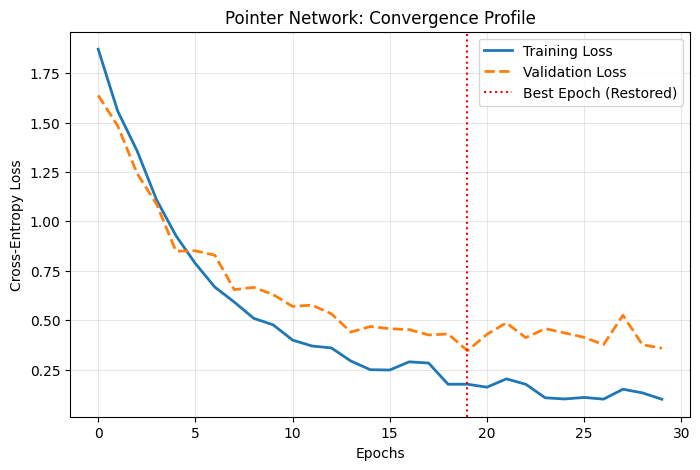

Model weights and plot data saved to: /home/eman/signly/data/built_corpus_supa/pointer_net_weights.pth

Inference Running on 63 Aligned Test Sequences
Example 1:
Source (NLP) : حكالي اثنان صاحب أن كتاب مفيد
Target (ArSL): صاحب اثنان حكالي | أن كتاب مفيد
Prediction   : صاحب اثنان حكالي أن كتاب مفيد
--------------------------------------------------
Example 2:
Source (NLP) : قبل شفى كثير مفتاح
Target (ArSL): مفتاح كثير قبل شفى
Prediction   : مفتاح كثير قبل شفى
--------------------------------------------------
Example 3:
Source (NLP) : أن ولد جوعان قبل طلب طالب أكل
Target (ArSL): أن ولد جوعان | طالب أكل قبل طلب
Prediction   : أن ولد جوعان طالب أكل قبل طلب
--------------------------------------------------
Example 4:
Source (NLP) : موظف قبل طلب شاي
Target (ArSL): موظف شاي قبل طلب
Prediction   : موظف شاي قبل طلب
--------------------------------------------------
Example 5:
Source (NLP) : اثنان قبل قرأ طالب قبل نص ممتع طويل
Target (ArSL): طالب اثنان نص طويل ممتع قبل قرأ
Prediction   : طالب 

In [3]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from scipy import stats
import sys
from dotenv import load_dotenv

current_dir = os.path.abspath(os.getcwd())
root_dir = current_dir

while root_dir and not os.path.exists(os.path.join(root_dir, 'backend')):
    parent = os.path.dirname(root_dir)
    if parent == root_dir:
        break
    root_dir = parent

backend_dir = os.path.join(root_dir, 'backend')

env_path_root = os.path.join(root_dir, '.env')
env_path_backend = os.path.join(backend_dir, '.env')

if os.path.exists(env_path_root):
    load_dotenv(dotenv_path=env_path_root)
    print(f"Loaded environment variables from: {env_path_root}")
elif os.path.exists(env_path_backend):
    load_dotenv(dotenv_path=env_path_backend)
    print(f"Loaded environment variables from: {env_path_backend}")

if os.path.exists(backend_dir):
    if backend_dir not in sys.path:
        sys.path.append(backend_dir)
else:
    print(f"CRITICAL ERROR: Could not find backend directory starting from {current_dir}")

from app.core.nlp_utils import transform_to_arsl

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EMBED_MODEL = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2').to(DEVICE)
HIDDEN_DIM = 512
LR = 1e-3
BATCH_SIZE = 16
MAX_LEN = 20
NUM_EPOCHS = 80

WEIGHT_DECAY = 1e-4  # L2
DROPOUT_RATE = 0.3   
PATIENCE = 10

FORCE_RETRAIN = True  #  True to ignore saved weights and retrain from scratch

DATA_DIR = os.path.join(root_dir, 'data', 'built_corpus_supa')

PATH_MASTER_NLP_OUT = os.path.join(DATA_DIR, 'mixed_sentences_jordanian_nlp_processed.txt')
PATH_MASTER_TARGET = os.path.join(DATA_DIR, 'mixed_sentences_jordanian_target.txt')
PATH_TRAIN_NLP_OUT = os.path.join(DATA_DIR, 'split_train-nlp-processed.txt')
PATH_TRAIN_TARGET = os.path.join(DATA_DIR, 'split_train-targets.txt')
PATH_VAL_NLP_OUT = os.path.join(DATA_DIR, 'split_val-nlp-processed.txt')
PATH_VAL_TARGET = os.path.join(DATA_DIR, 'split_val-targets.txt')
PATH_TEST_NLP_OUT = os.path.join(DATA_DIR, 'split_test-nlp-processed.txt')
PATH_TEST_TARGET = os.path.join(DATA_DIR, 'split_test-targets.txt')

MODEL_SAVE_PATH = os.path.join(DATA_DIR, 'pointer_net_weights.pth')


def split_master_dataset(src_path, tgt_path, train_ratio=0.8, val_ratio=0.1):
    if not os.path.exists(src_path) or not os.path.exists(tgt_path):
        print("Skipping dataset split: Master files not found.")
        return
        
    with open(src_path, 'r', encoding='utf-8') as f:
        src_lines = [l.strip() for l in f if l.strip()]
        
    with open(tgt_path, 'r', encoding='utf-8') as f:
        tgt_lines = []
        for l in f:
            clean_l = l.strip()
            if not clean_l: continue
            if clean_l.startswith("Output:"):
                clean_l = clean_l.replace("Output:", "", 1).strip()
            tgt_lines.append(clean_l)

    assert len(src_lines) == len(tgt_lines), "Lines mismatch!"
    total_lines = len(src_lines)
    
    combined = list(zip(src_lines, tgt_lines))
    random.seed(42) 
    random.shuffle(combined)
    src_lines_shuffled, tgt_lines_shuffled = zip(*combined)

    train_end = int(total_lines * train_ratio)
    val_end = train_end + int(total_lines * val_ratio)

    splits = {
        'train': (src_lines_shuffled[:train_end], tgt_lines_shuffled[:train_end], PATH_TRAIN_NLP_OUT, PATH_TRAIN_TARGET),
        'val': (src_lines_shuffled[train_end:val_end], tgt_lines_shuffled[train_end:val_end], PATH_VAL_NLP_OUT, PATH_VAL_TARGET),
        'test': (src_lines_shuffled[val_end:], tgt_lines_shuffled[val_end:], PATH_TEST_NLP_OUT, PATH_TEST_TARGET)
    }

    for split_name, (src_data, tgt_data, src_out_path, tgt_out_path) in splits.items():
        with open(src_out_path, 'w', encoding='utf-8') as f: f.write('\n'.join(src_data) + '\n')
        with open(tgt_out_path, 'w', encoding='utf-8') as f: f.write('\n'.join(tgt_data) + '\n')


def load_aligned_data(src_path, tgt_path):
    with open(src_path, 'r', encoding='utf-8') as f: src_lines = [l.strip() for l in f if l.strip()]
    with open(tgt_path, 'r', encoding='utf-8') as f:
        tgt_lines = []
        for l in f:
            clean_l = l.strip()
            if not clean_l: continue
            if clean_l.startswith("Output:"): clean_l = clean_l.replace("Output:", "", 1).strip()
            tgt_lines.append(clean_l)
    return src_lines, tgt_lines


class PointerDataset(Dataset):
    def __init__(self, src_lines, tgt_lines):
        self.src_lines = src_lines
        self.tgt_lines = tgt_lines

    def __len__(self): return len(self.src_lines)

    def __getitem__(self, idx):
        source_words = self.src_lines[idx].split()[:MAX_LEN]
        target_words = self.tgt_lines[idx].split()[:MAX_LEN]

        target_indices = []
        for word in target_words:
            if word in source_words: target_indices.append(source_words.index(word))
            else: target_indices.append(0)

        embeddings = EMBED_MODEL.encode(source_words)
        padded_embeds = np.zeros((MAX_LEN, 384))
        padded_embeds[:len(source_words)] = embeddings

        padded_targets = np.full(MAX_LEN, -1)
        padded_targets[:len(target_indices)] = target_indices

        return torch.FloatTensor(padded_embeds), torch.LongTensor(padded_targets), len(source_words)


class PointerAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.vt = nn.Linear(hidden_dim, 1)

    def forward(self, decoder_hidden, encoder_outputs):
        out = torch.tanh(self.W1(encoder_outputs) + self.W2(decoder_hidden).unsqueeze(1))
        scores = self.vt(out).squeeze(2)
        return scores


class PointerNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate=DROPOUT_RATE):
        super().__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.decoder = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.attention = PointerAttention(hidden_dim)
        self.reduce_h = nn.Linear(hidden_dim * 2, hidden_dim)
        self.reduce_c = nn.Linear(hidden_dim * 2, hidden_dim)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        x = self.dropout(x)
        enc_out, (h_n, c_n) = self.encoder(x)
        enc_out = self.dropout(enc_out)

        h_d = self.reduce_h(torch.cat((h_n[0], h_n[1]), dim=1)).unsqueeze(0)
        c_d = self.reduce_c(torch.cat((c_n[0], c_n[1]), dim=1)).unsqueeze(0)

        enc_out_reduced = enc_out[:, :, :HIDDEN_DIM] + enc_out[:, :, HIDDEN_DIM:]
        all_logits = []
        decoder_input = torch.zeros(batch_size, 1, HIDDEN_DIM).to(DEVICE)

        for _ in range(seq_len):
            _, (h_d, c_d) = self.decoder(decoder_input, (h_d, c_d))
            h_d_dropped = self.dropout(h_d)
            logits = self.attention(h_d_dropped.squeeze(0), enc_out_reduced)
            all_logits.append(logits)

        return torch.stack(all_logits, dim=1)


def plot_convergence(history, best_epoch_idx):
    """Plots the training/validation loss curve."""
    plt.figure(figsize=(8, 5))
    plt.plot(history['train_loss'], label='Training Loss', lw=2)
    plt.plot(history['val_loss'], label='Validation Loss', lw=2, linestyle='--')
    
    if best_epoch_idx >= 0:
        plt.axvline(x=best_epoch_idx, color='r', linestyle=':', label='Best Epoch (Restored)')
        
    plt.title("Pointer Network: Convergence Profile")
    plt.xlabel("Epochs")
    plt.ylabel("Cross-Entropy Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def train_and_validate(train_loader, val_loader, patience=PATIENCE):
    model = PointerNet(384, HIDDEN_DIM).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    history = {'train_loss': [], 'val_loss': []}

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_weights = None

    for epoch in range(NUM_EPOCHS):
        model.train()
        train_loss = 0
        for x, y, _ in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output.view(-1, MAX_LEN), y.view(-1))
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y, _ in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                output = model(x)
                loss = criterion(output.view(-1, MAX_LEN), y.view(-1))
                val_loss += loss.item()

        avg_train = train_loss / len(train_loader)
        avg_val = val_loss / len(val_loader)
        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            patience_counter = 0
            best_model_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1

        if epoch % 10 == 0 or epoch == NUM_EPOCHS - 1 or patience_counter >= patience:
            print(f"Epoch [{epoch:02d}/{NUM_EPOCHS-1}] -> Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f} | Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"\n[!] Early stopping triggered at epoch {epoch}!")
            break
     
    if best_model_weights is not None:
        model.load_state_dict(best_model_weights)
        
    best_epoch_idx = len(history['val_loss']) - patience_counter - 1
    plot_convergence(history, best_epoch_idx)
    
    return model, history, best_epoch_idx


def compute_bootstrap_ci(metrics_list, confidence=0.95, n_resamples=1000):
    if not metrics_list: return 0.0, 0.0, 0.0
    means = []
    for _ in range(n_resamples):
        sample = random.choices(metrics_list, k=len(metrics_list))
        means.append(np.mean(sample))
    lower = np.percentile(means, ((1 - confidence) / 2) * 100)
    upper = np.percentile(means, (1 - (1 - confidence) / 2) * 100)
    return np.mean(metrics_list), lower, upper


def evaluate_on_test_set(model, src_lines, tgt_lines):
    model.eval()
    smooth_fn = SmoothingFunction().method1
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)

    bleu_scores, rouge_scores, exact_matches, kendall_taus = [], [], [], []

    print(f"\nInference Running on {len(src_lines)} Aligned Test Sequences")
    inspection_path = os.path.join(root_dir, 'predictions_inspection.txt')
    inspection_file = open(inspection_path, "w", encoding="utf-8")
    
    with torch.no_grad():
        for i, (src_sent, tgt_sent) in enumerate(zip(src_lines, tgt_lines)):
            src_words = src_sent.split()[:MAX_LEN]
            n = len(src_words)
            if n == 0: continue
            
            emb = torch.FloatTensor(EMBED_MODEL.encode(src_words)).unsqueeze(0).to(DEVICE)
            padded_x = torch.zeros(1, MAX_LEN, 384).to(DEVICE)
            padded_x[0, :n] = emb
            logits = model(padded_x)[0]

            indices = []
            mask = torch.zeros(n).to(DEVICE)
            for step in range(n):
                step_logits = logits[step, :n] + mask
                idx = torch.argmax(step_logits).item()
                indices.append(idx)
                mask[idx] = -1e9

            predicted_words = [src_words[idx] for idx in indices]
            pred_sent = " ".join(predicted_words)
            ref_words = tgt_sent.split()

            
            log_text = (
                f"Example {i+1}:\n"
                f"Source (NLP) : {src_sent}\n"
                f"Target (ArSL): {tgt_sent}\n"
                f"Prediction   : {pred_sent}\n"
                f"{'-'*50}\n"
            )
            inspection_file.write(log_text)
            if i < 5: print(log_text.strip())

            # Metrics
            b_score = sentence_bleu([ref_words], predicted_words, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth_fn)
            r_score = scorer.score(tgt_sent, pred_sent)['rougeL'].fmeasure
            em_score = 1.0 if pred_sent.strip() == tgt_sent.strip() else 0.0

            # KENDALL TAU CALCULATION
            target_idx = []
            valid_permutation = True
            for w in ref_words:
                if w in src_words: target_idx.append(src_words.index(w))
                else: valid_permutation = False; break
                
            if valid_permutation and len(target_idx) == len(indices):
                tau, _ = stats.kendalltau(target_idx, indices)
                if not np.isnan(tau): kendall_taus.append(max(0, tau)) # Floor at 0 for readability

            bleu_scores.append(b_score)
            rouge_scores.append(r_score)
            exact_matches.append(em_score)

    inspection_file.close()
    
    m_bleu, b_l, b_h = compute_bootstrap_ci(bleu_scores)
    m_rouge, r_l, r_h = compute_bootstrap_ci(rouge_scores)
    m_em, em_l, em_h = compute_bootstrap_ci(exact_matches)
    m_tau, tau_l, tau_h = compute_bootstrap_ci(kendall_taus)

    print("\n" + "="*65)
    print(f"{'EVALUATION METRICS':^65}")
    print("="*65)
    print(f"{'Metric':<15} | {'Mean Value':<12} | {'95% Confidence Interval (CI)':<30}")
    print("-"*65)
    print(f"{'Exact Match':<15} | {m_em*100:<12.2f}% | [{em_l*100:.2f}%, {em_h*100:.2f}%]  <- Binary pass/fail")
    print(f"{'BLEU-4':<15} | {m_bleu*100:<12.2f}% | [{b_l*100:.2f}%, {b_h*100:.2f}%]  <- Sub-phrase matching")
    print(f"{'ROUGE-L':<15} | {m_rouge*100:<12.2f}% | [{r_l*100:.2f}%, {r_h*100:.2f}%]")
    print(f"{'Kendall Tau':<15} | {m_tau*100:<12.2f}% | [{tau_l*100:.2f}%, {tau_h*100:.2f}%]  <- Sorting accuracy")
    print("="*65 + "\n")


def test_manual_sentences(model):
    print("\n" + "="*60)
    print(f"{'MANUAL INFERENCE TERMINAL':^60}")
    print("="*60)
    print("Type an Arabic sentence to test the model.")
    print("Type 'q' or 'quit' to exit.\n")
    
    model.eval()
    while True:
        user_input = input(">> Enter Arabic Text: ").strip()
        if user_input.lower() in ['q', 'quit', 'exit']:
            break
        if not user_input:
            continue
            
        try:
            # process raw string to NLP format
            processed_words = transform_to_arsl(user_input)
            if not processed_words:
                print("NLP Pipeline returned empty list.\n")
                continue
                
            src_words = processed_words[:MAX_LEN]
            n = len(src_words)
            
            # vectorize
            emb = torch.FloatTensor(EMBED_MODEL.encode(src_words)).unsqueeze(0).to(DEVICE)
            padded_x = torch.zeros(1, MAX_LEN, 384).to(DEVICE)
            padded_x[0, :n] = emb
            
            with torch.no_grad(): # reorder
                logits = model(padded_x)[0]
                indices = []
                mask = torch.zeros(n).to(DEVICE)
                for step in range(n):
                    step_logits = logits[step, :n] + mask
                    idx = torch.argmax(step_logits).item()
                    indices.append(idx)
                    mask[idx] = -1e9
                    
            predicted_words = [src_words[idx] for idx in indices]
            
            print(f"NLP Tokens  : {' '.join(src_words)}")
            print(f"ArSL Output : {' '.join(predicted_words)}\n")
            
        except Exception as e:
            print(f"Error processing input: {e}\n")


if __name__ == "__main__":
    
    split_master_dataset(PATH_MASTER_NLP_OUT, PATH_MASTER_TARGET)

    train_src_lines, train_tgt_lines = load_aligned_data(PATH_TRAIN_NLP_OUT, PATH_TRAIN_TARGET)
    val_src_lines, val_tgt_lines = load_aligned_data(PATH_VAL_NLP_OUT, PATH_VAL_TARGET)
    test_src_lines, test_tgt_lines = load_aligned_data(PATH_TEST_NLP_OUT, PATH_TEST_TARGET)

    model = PointerNet(384, HIDDEN_DIM).to(DEVICE)

    if os.path.exists(MODEL_SAVE_PATH) and not FORCE_RETRAIN:
        print(f"\n[!] Found existing weights at {MODEL_SAVE_PATH}")
        print("Loading model without retraining...")
        
        checkpoint = torch.load(MODEL_SAVE_PATH, map_location=DEVICE)
        
        # Check if it's the new format that contains the plot history
        if isinstance(checkpoint, dict) and 'model_state' in checkpoint:
            model.load_state_dict(checkpoint['model_state'])
            plot_convergence(checkpoint['history'], checkpoint['best_epoch_idx'])
        else:
            # Fallback for the older save format
            model.load_state_dict(checkpoint)
            print("[Note] Old model save format detected. Set FORCE_RETRAIN = True once to save the plot data for next time!")
            
    else:
        if FORCE_RETRAIN:
            print("\n[!] FORCE_RETRAIN is set to True. Ignoring saved weights and training new model...")
        else:
            print("\n[!] No existing weights found. Training new model...")
            
        train_ds = PointerDataset(train_src_lines, train_tgt_lines)
        val_ds = PointerDataset(val_src_lines, val_tgt_lines)
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

        # Train and capture history for plotting
        model, history, best_epoch_idx = train_and_validate(train_loader, val_loader)
        
        torch.save({
            'model_state': model.state_dict(),
            'history': history,
            'best_epoch_idx': best_epoch_idx
        }, MODEL_SAVE_PATH)
        print(f"Model weights and plot data saved to: {MODEL_SAVE_PATH}")

    evaluate_on_test_set(model, test_src_lines, test_tgt_lines)
    test_manual_sentences(model)

In [ ]:
test_manual_sentences(model)


                 MANUAL INFERENCE TERMINAL                  
Type an Arabic sentence to test the model.
Type 'q' or 'quit' to exit.

transform_to_arsl received: 'فنجان القهوة على الطاولة'
DEBUG arsl_sequence before N-gram: ['كثير', 'جانى', 'قهوة', 'طاولة']
NLP Tokens  : كثير جانى قهوة طاولة
ArSL Output : جانى كثير قهوة طاولة

transform_to_arsl received: 'كأس الشاي على الطاولة'
DEBUG arsl_sequence before N-gram: ['كاس', 'شاي', 'طاولة']
NLP Tokens  : كاس شاي طاولة
ArSL Output : كاس شاي طاولة

transform_to_arsl received: 'لا شأن لك'
DEBUG arsl_sequence before N-gram: ['شأن', 'لا']
NLP Tokens  : شأن لا
ArSL Output : شأن لا

transform_to_arsl received: 'انا حر'
DEBUG arsl_sequence before N-gram: ['أنا', 'حر']
NLP Tokens  : أنا حر
ArSL Output : أنا حر

transform_to_arsl received: 'المملكة الاردنية الهاشمية'
DEBUG arsl_sequence before N-gram: ['مملكة', 'أردني', 'هاشمي']
NLP Tokens  : مملكة أردني هاشمي
ArSL Output : مملكة هاشمي أردني

transform_to_arsl received: 'الجامعة الاردنية'
DEBUG arsl_

loaded environment variables from: /home/eman/signly/backend/.env
Loaded and cleaned 600 total paired sequences from master files.
Exported TRAIN split (480 lines) to split_train-nlp-processed.txt and split_train-targets.txt
Exported VAL split (60 lines) to split_val-nlp-processed.txt and split_val-targets.txt
Exported TEST split (60 lines) to split_test-nlp-processed.txt and split_test-targets.txt
Dataset splitting complete.

Epoch [00/79] -> Train Loss: 1.9123 | Val Loss: 1.6955 | Patience: 0/10
Epoch [10/79] -> Train Loss: 0.2021 | Val Loss: 0.2662 | Patience: 1/10
Epoch [20/79] -> Train Loss: 0.0876 | Val Loss: 0.2247 | Patience: 6/10
Epoch [24/79] -> Train Loss: 0.0832 | Val Loss: 0.2155 | Patience: 10/10

[!] Early stopping triggered at epoch 24!
Restoring best model weights (Validation Loss: 0.2010)


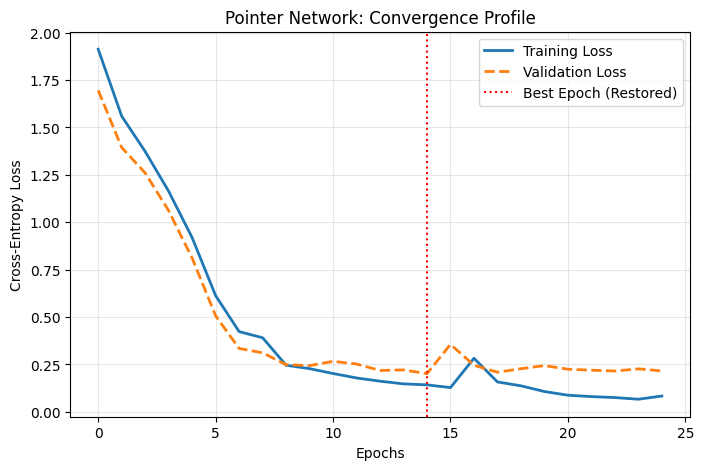


Inference Running on 60 Aligned Test Sequences
Example 1:
Source (NLP) : قبل قاد أخ سوق ظهر .
Target (ArSL): ظهر أخ سوق قبل قاد .
Prediction   : ظهر أخ سوق قبل قاد .
--------------------------------------------------
Example 2:
Source (NLP) : بائع قبل لعب كامرا غد .
Target (ArSL): غد بائع كامرا قبل لعب .
Prediction   : غد بائع كامرا قبل لعب .
--------------------------------------------------
Example 3:
Source (NLP) : آن قبل أكل لوز شارع .
Target (ArSL): آن لوز شارع قبل أكل .
Prediction   : آن لوز شارع قبل أكل .
--------------------------------------------------
Example 4:
Source (NLP) : أخ قبل أكل طعام آن .
Target (ArSL): آن أخ طعام قبل أكل .
Prediction   : آن أخ طعام قبل أكل .
--------------------------------------------------
Example 5:
Source (NLP) : آن قبل لعب طفل قهوة .
Target (ArSL): آن طفل قهوة قبل لعب .
Prediction   : آن طفل قهوة قبل لعب .
--------------------------------------------------

[!] Saved full prediction log to '/home/eman/signly/predictions_inspection.txt' for ma

In [ ]:
# TODO: [v] Test sentences manually 
#       [v] Different metrics (kendall tau?) 
#       [v] Use the newly generated data (including our glossary), preprocess and train 
#       []  Add a condition to handle composite nouns ie عملية جراحية
#       [] Generate data of dialects too (inc size?) with a feature as MSA or JO
#       [] Train and plot 2 curves of each case with specified metrics
      
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from scipy import stats
import sys
from dotenv import load_dotenv

current_dir = os.path.abspath(os.getcwd())
root_dir = current_dir

while root_dir and not os.path.exists(os.path.join(root_dir, 'backend')):
    parent = os.path.dirname(root_dir)
    if parent == root_dir:
        break
    root_dir = parent

backend_dir = os.path.join(root_dir, 'backend')

env_path_root = os.path.join(root_dir, '.env')
env_path_backend = os.path.join(backend_dir, '.env')

if os.path.exists(env_path_root):
    load_dotenv(dotenv_path=env_path_root)
    print(f"loaded environment variables from: {env_path_root}")
elif os.path.exists(env_path_backend):
    load_dotenv(dotenv_path=env_path_backend)
    print(f"loaded environment variables from: {env_path_backend}")

if os.path.exists(backend_dir):
    if backend_dir not in sys.path:
        sys.path.append(backend_dir)
else:
    print(f"CRITICAL ERROR: Could not find backend directory starting from {current_dir}")

try:
    from app.core.nlp_utils import transform_to_arsl
except ImportError:
    pass

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EMBED_MODEL = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2').to(DEVICE)
HIDDEN_DIM = 512
LR = 1e-3
BATCH_SIZE = 16
MAX_LEN = 20
NUM_EPOCHS = 80

WEIGHT_DECAY = 1e-4  # L2
DROPOUT_RATE = 0.3   
PATIENCE = 10

DATA_DIR = os.path.join(root_dir, 'data', 'built_corpus')

PATH_MASTER_NLP_OUT = os.path.join(DATA_DIR, 'sentences_nlp_processed.txt')
PATH_MASTER_TARGET = os.path.join(DATA_DIR, 'sentences_target.txt')

# GENERATED SPLIT PATHS
PATH_TRAIN_NLP_OUT = os.path.join(DATA_DIR, 'split_train-nlp-processed.txt')
PATH_TRAIN_TARGET = os.path.join(DATA_DIR, 'split_train-targets.txt')

PATH_VAL_NLP_OUT = os.path.join(DATA_DIR, 'split_val-nlp-processed.txt')
PATH_VAL_TARGET = os.path.join(DATA_DIR, 'split_val-targets.txt')

PATH_TEST_NLP_OUT = os.path.join(DATA_DIR, 'split_test-nlp-processed.txt')
PATH_TEST_TARGET = os.path.join(DATA_DIR, 'split_test-targets.txt')


def split_master_dataset(src_path, tgt_path, train_ratio=0.8, val_ratio=0.1):
    """
    Reads the master aligned files, cleans ONLY the target file, shuffles them in unison, 
    splits them, and exports them into 3 new sets of files (Train, Val, Test).
    """
    if not os.path.exists(src_path) or not os.path.exists(tgt_path):
        raise FileNotFoundError(f"Master files not found! Please ensure both {src_path} and {tgt_path} exist.")
        
    # Read source files (ALREADY PROCESSED, NO CLEANING NEEDED)
    with open(src_path, 'r', encoding='utf-8') as f:
        src_lines = [l.strip() for l in f if l.strip()]
        
    # Read and CLEAN target lines ("Output: ")
    with open(tgt_path, 'r', encoding='utf-8') as f:
        tgt_lines = []
        for l in f:
            clean_l = l.strip()
            if not clean_l: 
                continue
            # Strip out the erroneous "Output: " prefix from targets
            if clean_l.startswith("Output:"):
                clean_l = clean_l.replace("Output:", "", 1).strip()
            tgt_lines.append(clean_l)

    assert len(src_lines) == len(tgt_lines), f"Lines mismatch! Src: {len(src_lines)} vs Tgt: {len(tgt_lines)}"
    
    total_lines = len(src_lines)
    print(f"Loaded and cleaned {total_lines} total paired sequences from master files.")

    combined = list(zip(src_lines, tgt_lines))
    random.seed(42) 
    random.shuffle(combined)
    src_lines_shuffled, tgt_lines_shuffled = zip(*combined)

    train_end = int(total_lines * train_ratio)
    val_end = train_end + int(total_lines * val_ratio)

    splits = {
        'train': (src_lines_shuffled[:train_end], tgt_lines_shuffled[:train_end], PATH_TRAIN_NLP_OUT, PATH_TRAIN_TARGET),
        'val': (src_lines_shuffled[train_end:val_end], tgt_lines_shuffled[train_end:val_end], PATH_VAL_NLP_OUT, PATH_VAL_TARGET),
        'test': (src_lines_shuffled[val_end:], tgt_lines_shuffled[val_end:], PATH_TEST_NLP_OUT, PATH_TEST_TARGET)
    }

    for split_name, (src_data, tgt_data, src_out_path, tgt_out_path) in splits.items():
        with open(src_out_path, 'w', encoding='utf-8') as f:
            f.write('\n'.join(src_data) + '\n')
        with open(tgt_out_path, 'w', encoding='utf-8') as f:
            f.write('\n'.join(tgt_data) + '\n')
        print(f"Exported {split_name.upper()} split ({len(src_data)} lines) to {os.path.basename(src_out_path)} and {os.path.basename(tgt_out_path)}")
        
    print("Dataset splitting complete.\n")


def load_aligned_data(src_path, tgt_path):
    if not os.path.exists(src_path) or not os.path.exists(tgt_path):
        raise FileNotFoundError(f"Missing files! Src: {src_path} | Tgt: {tgt_path}")
        
    with open(src_path, 'r', encoding='utf-8') as f:
        src_lines = [l.strip() for l in f if l.strip()]
        
    # Read the target files (Fail-safe check just in case)
    with open(tgt_path, 'r', encoding='utf-8') as f:
        tgt_lines = []
        for l in f:
            clean_l = l.strip()
            if not clean_l: 
                continue
            if clean_l.startswith("Output:"):
                clean_l = clean_l.replace("Output:", "", 1).strip()
            tgt_lines.append(clean_l)
    
    assert len(src_lines) == len(tgt_lines), f"Mismatched dataset lengths in {src_path}. Src: {len(src_lines)}, Tgt: {len(tgt_lines)}"
    return src_lines, tgt_lines


class PointerDataset(Dataset):
    def __init__(self, src_lines, tgt_lines):
        self.src_lines = src_lines
        self.tgt_lines = tgt_lines

    def __len__(self): 
        return len(self.src_lines)

    def __getitem__(self, idx):
        source_words = self.src_lines[idx].split()[:MAX_LEN]
        target_words = self.tgt_lines[idx].split()[:MAX_LEN]

        target_indices = []
        for word in target_words:
            if word in source_words:
                target_indices.append(source_words.index(word))
            else:
                target_indices.append(0)

        embeddings = EMBED_MODEL.encode(source_words)
        padded_embeds = np.zeros((MAX_LEN, 384))
        padded_embeds[:len(source_words)] = embeddings

        padded_targets = np.full(MAX_LEN, -1)
        padded_targets[:len(target_indices)] = target_indices

        return torch.FloatTensor(padded_embeds), torch.LongTensor(padded_targets), len(source_words)


# ptr net
class PointerAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.vt = nn.Linear(hidden_dim, 1)

    def forward(self, decoder_hidden, encoder_outputs):
        out = torch.tanh(self.W1(encoder_outputs) + self.W2(decoder_hidden).unsqueeze(1))
        scores = self.vt(out).squeeze(2)
        return scores


class PointerNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate=DROPOUT_RATE):
        super().__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.decoder = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.attention = PointerAttention(hidden_dim)
        self.reduce_h = nn.Linear(hidden_dim * 2, hidden_dim)
        self.reduce_c = nn.Linear(hidden_dim * 2, hidden_dim)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        x = self.dropout(x)
        enc_out, (h_n, c_n) = self.encoder(x)
        enc_out = self.dropout(enc_out)

        h_d = self.reduce_h(torch.cat((h_n[0], h_n[1]), dim=1)).unsqueeze(0)
        c_d = self.reduce_c(torch.cat((c_n[0], c_n[1]), dim=1)).unsqueeze(0)

        enc_out_reduced = enc_out[:, :, :HIDDEN_DIM] + enc_out[:, :, HIDDEN_DIM:]
        all_logits = []
        decoder_input = torch.zeros(batch_size, 1, HIDDEN_DIM).to(DEVICE)

        for _ in range(seq_len):
            _, (h_d, c_d) = self.decoder(decoder_input, (h_d, c_d))
            h_d_dropped = self.dropout(h_d)
            logits = self.attention(h_d_dropped.squeeze(0), enc_out_reduced)
            all_logits.append(logits)

        return torch.stack(all_logits, dim=1)


def train_and_validate(train_loader, val_loader, patience=PATIENCE):
    model = PointerNet(384, HIDDEN_DIM).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    history = {'train_loss': [], 'val_loss': []}

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_weights = None

    for epoch in range(NUM_EPOCHS):
        model.train()
        train_loss = 0
        for x, y, _ in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output.view(-1, MAX_LEN), y.view(-1))
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y, _ in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                output = model(x)
                loss = criterion(output.view(-1, MAX_LEN), y.view(-1))
                val_loss += loss.item()

        avg_train = train_loss / len(train_loader)
        avg_val = val_loss / len(val_loader)
        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            patience_counter = 0
            best_model_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1

        if epoch % 10 == 0 or epoch == NUM_EPOCHS - 1 or patience_counter >= patience:
            print(f"Epoch [{epoch:02d}/{NUM_EPOCHS-1}] -> Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f} | Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"\n[!] Early stopping triggered at epoch {epoch}!")
            print(f"Restoring best model weights (Validation Loss: {best_val_loss:.4f})")
            break
     
    if best_model_weights is not None:
        model.load_state_dict(best_model_weights)

    best_epoch_idx = len(history['val_loss']) - patience_counter - 1
    plt.figure(figsize=(8, 5))
    plt.plot(history['train_loss'], label='Training Loss', lw=2)
    plt.plot(history['val_loss'], label='Validation Loss', lw=2, linestyle='--')
    
    if best_epoch_idx >= 0:
        plt.axvline(x=best_epoch_idx, color='r', linestyle=':', label='Best Epoch (Restored)')
        
    plt.title("Pointer Network: Convergence Profile")
    plt.xlabel("Epochs")
    plt.ylabel("Cross-Entropy Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return model


def compute_bootstrap_ci(metrics_list, confidence=0.95, n_resamples=1000):
    means = []
    for _ in range(n_resamples):
        sample = random.choices(metrics_list, k=len(metrics_list))
        means.append(np.mean(sample))
    lower = np.percentile(means, ((1 - confidence) / 2) * 100)
    upper = np.percentile(means, (1 - (1 - confidence) / 2) * 100)
    return np.mean(metrics_list), lower, upper


def evaluate_on_test_set(model, src_lines, tgt_lines):
    model.eval()
    smooth_fn = SmoothingFunction().method1
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)

    bleu_scores = []
    rouge_scores = []
    exact_matches = []

    print(f"\nInference Running on {len(src_lines)} Aligned Test Sequences")
    inspection_path = os.path.join(root_dir, 'predictions_inspection.txt')
    inspection_file = open(inspection_path, "w", encoding="utf-8")
    
    with torch.no_grad():
        for i, (src_sent, tgt_sent) in enumerate(zip(src_lines, tgt_lines)):
            src_words = src_sent.split()[:MAX_LEN]
            n = len(src_words)
            if n == 0: continue
            
            emb = torch.FloatTensor(EMBED_MODEL.encode(src_words)).unsqueeze(0).to(DEVICE)
            padded_x = torch.zeros(1, MAX_LEN, 384).to(DEVICE)
            padded_x[0, :n] = emb
            logits = model(padded_x)[0]

            indices = []
            mask = torch.zeros(n).to(DEVICE)
            for step in range(n):
                step_logits = logits[step, :n] + mask
                idx = torch.argmax(step_logits).item()
                indices.append(idx)
                mask[idx] = -1e9

            predicted_words = [src_words[idx] for idx in indices]
            pred_sent = " ".join(predicted_words)
            ref_words = tgt_sent.split()

            log_text = (
                f"Example {i+1}:\n"
                f"Source (NLP) : {src_sent}\n"
                f"Target (ArSL): {tgt_sent}\n"
                f"Prediction   : {pred_sent}\n"
                f"{'-'*50}\n"
            )
            inspection_file.write(log_text)
            
            if i < 5:
                print(log_text.strip())

            b_score = sentence_bleu([ref_words], predicted_words, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth_fn)
            r_score = scorer.score(tgt_sent, pred_sent)['rougeL'].fmeasure
            em_score = 1.0 if pred_sent.strip() == tgt_sent.strip() else 0.0

            bleu_scores.append(b_score)
            rouge_scores.append(r_score)
            exact_matches.append(em_score)

    inspection_file.close()
    print(f"\n[!] Saved full prediction log to '{inspection_path}' for manual review.")
    
    mean_bleu, b_low, b_high = compute_bootstrap_ci(bleu_scores)
    mean_rouge, r_low, r_high = compute_bootstrap_ci(rouge_scores)
    mean_em, em_low, em_high = compute_bootstrap_ci(exact_matches)

    print("\n" + "="*60)
    print("Evaluation Metrics")
    print("="*60)
    print(f"{'Metric':<15} | {'Mean Value':<12} | {'95% Confidence Interval (CI)':<30}")
    print("-"*60)
    print(f"{'BLEU-4':<15} | {mean_bleu*100:<12.2f}% | [{b_low*100:.2f}%, {b_high*100:.2f}%]")
    print(f"{'ROUGE-L':<15} | {mean_rouge*100:<12.2f}% | [{r_low*100:.2f}%, {r_high*100:.2f}%]")
    print(f"{'Exact Match':<15} | {mean_em*100:<12.2f}% | [{em_low*100:.2f}%, {em_high*100:.2f}%]")
    print("="*60 + "\n")


if __name__ == "__main__":
    
    split_master_dataset(PATH_MASTER_NLP_OUT, PATH_MASTER_TARGET)

    train_src_lines, train_tgt_lines = load_aligned_data(PATH_TRAIN_NLP_OUT, PATH_TRAIN_TARGET)
    val_src_lines, val_tgt_lines = load_aligned_data(PATH_VAL_NLP_OUT, PATH_VAL_TARGET)
    test_src_lines, test_tgt_lines = load_aligned_data(PATH_TEST_NLP_OUT, PATH_TEST_TARGET)

    # 3. Instantiate datasets
    train_ds = PointerDataset(train_src_lines, train_tgt_lines)
    val_ds = PointerDataset(val_src_lines, val_tgt_lines)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    trained_model = train_and_validate(train_loader, val_loader)

    evaluate_on_test_set(trained_model, test_src_lines, test_tgt_lines)

In [ ]:
def test_manual_sentences(model):
    """Allows manual string input testing without retraining."""
    print("\n" + "="*60)
    print(f"{'MANUAL INFERENCE TERMINAL':^60}")
    print("="*60)
    print("Type an Arabic sentence to test the model.")
    print("Type 'q' or 'quit' to exit.\n")
    
    model.eval()
    while True:
        user_input = input(">> Enter Arabic Text: ").strip()
        if user_input.lower() in ['q', 'quit', 'exit']:
            break
        if not user_input:
            continue
            
        try:
            # 1. Process raw string to NLP format
            processed_words = transform_to_arsl(user_input)
            if not processed_words:
                print("NLP Pipeline returned empty list.\n")
                continue
                
            src_words = processed_words[:MAX_LEN]
            n = len(src_words)
            
            # 2. Vectorize
            emb = torch.FloatTensor(EMBED_MODEL.encode(src_words)).unsqueeze(0).to(DEVICE)
            padded_x = torch.zeros(1, MAX_LEN, 384).to(DEVICE)
            padded_x[0, :n] = emb
            
            # 3. Predict Reordering
            with torch.no_grad():
                logits = model(padded_x)[0]
                indices = []
                mask = torch.zeros(n).to(DEVICE)
                for step in range(n):
                    step_logits = logits[step, :n] + mask
                    idx = torch.argmax(step_logits).item()
                    indices.append(idx)
                    mask[idx] = -1e9
                    
            predicted_words = [src_words[idx] for idx in indices]
            
            print(f"NLP Tokens  : {' '.join(src_words)}")
            print(f"ArSL Output : {' '.join(predicted_words)}\n")
            
        except Exception as e:
            print(f"Error processing input: {e}\n")


    test_manual_sentences(model)

In [14]:
torch.save(model.state_dict(), "pointer_net_arsl.pth")

print(reorder_sentence_hybrid(model, "أين غرفة المعيشة؟"))

؟ غرفة المعيشة أين


In [15]:
print(reorder_sentence_hybrid(model, "فنجان قهوة"))

فنجان قهوة
